### Overview
Cardiovascular diseases (CVDs), including heart disease, are the leading cause of death worldwide. Early detection of heart disease is critical for preventing serious health outcomes and improving the quality of life for patients. With the increasing availability of medical data, machine learning models can be used to predict whether a patient is likely to develop heart disease based on certain health indicators.

In this project, you will build a classification model to predict whether an individual is likely to have heart disease or not. The dataset provided includes various health and demographic factors such as age, blood pressure, cholesterol levels, and lifestyle habits (e.g., smoking and alcohol consumption). The goal is to train a model to identify which individuals have heart disease based on these features.


### Problem Statement
You are provided with a dataset that contains health-related information about individuals. Your task is to develop a machine learning model that can predict the presence of heart disease based on the provided features. The target variable in the dataset is "disease," which indicates whether a person has heart disease (1) or not (0).



In [ ]:
# Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

import warnings

warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("Data_file - data_file (2).csv")
df.head()

In [ ]:
# Drop any unnecessary columns (for example, 'id', 'date')
df.drop(['id', 'date'], axis=1, inplace=True)

In [ ]:
print(df.isnull().sum())

In [ ]:
df.info()

In [ ]:
#distribution of target varibel

sns.countplot(x='disease',data=df)
plt.title('distribution of disease')
plt.show()

### Exploratory Data Analysis

In [ ]:
#correaltion matrix

num_cols= list()

for column in df.columns:
    if df[column].dtype!=object:
        num_cols.append(column)

correlation_matrix=df[num_cols].corr()
plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm')
plt.title('correlation matrix')
plt.show()

In [ ]:
# Visualize the distribution of key features
plt.figure(figsize=(12,6))
sns.histplot(df['age'], kde=True)
plt.title('Age Distribution')
plt.show()

### Data Processsing

In [ ]:
# Convert categorical variables to numerical ones
label_encoder = LabelEncoder()
df['country'] = label_encoder.fit_transform(df['country'])
df['occupation'] = label_encoder.fit_transform(df['occupation'])

In [ ]:
# Define features (X) and target variable (y)
X = df.drop('disease', axis=1)
y = df['disease']

In [ ]:
### Model Building

In [ ]:
#split data into training and testing sets
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=0)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Logistic Regression

In [ ]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)

In [ ]:
logreg_accuracy = accuracy_score(y_test, logreg_pred)

In [ ]:
## Display accuracy and performance metrics

accuracy_percent = logreg_accuracy * 100
print("Logistic Regression Accuracy:", accuracy_percent, "%")
print('\nLogistic Regression Classification Report:')
print(classification_report(y_test, logreg_pred))

### Decision Tree Algorithm

In [34]:
decision_tree=DecisionTreeClassifier()
decision_tree.fit(X_train,y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [35]:
decision_tree_pred=decision_tree.predict(X_test)
decision_tree_accuracy=accuracy_score(y_test,decision_tree_pred)

In [36]:
print(f'decision tree Accuracy: {decision_tree_accuracy * 100:.2f}%')
print('\ndecision tree Classification Report:')
print(classification_report(y_test, decision_tree_pred))

decision tree Accuracy: 63.67%

decision tree Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.64      0.64      8820
           1       0.63      0.63      0.63      8680

    accuracy                           0.64     17500
   macro avg       0.64      0.64      0.64     17500
weighted avg       0.64      0.64      0.64     17500



### Support Vector Machine Algorithm

In [37]:
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [38]:
svm_pred =svm.predict(X_test)
svm_accuracy=accuracy_score(y_test,svm_pred)

In [39]:
print(f'Support Vector Machine Accuracy: {svm_accuracy*100:.2f}%')
print('\ndecision tree Classification Report:')
print(classification_report(y_test, decision_tree_pred))


Support Vector Machine Accuracy: 72.18%

decision tree Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.64      0.64      8820
           1       0.63      0.63      0.63      8680

    accuracy                           0.64     17500
   macro avg       0.64      0.64      0.64     17500
weighted avg       0.64      0.64      0.64     17500



### Model Comparision

In [43]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(y_test, y_pred, model_name):
    
    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{model_name} Accuracy: {accuracy*100:.2f}%\n")
    
    # Classification Report
    print(f"{model_name} Classification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    conf_matrix = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

Logistic Regression Accuracy: 72.16%

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.77      0.74      8820
           1       0.74      0.67      0.71      8680

    accuracy                           0.72     17500
   macro avg       0.72      0.72      0.72     17500
weighted avg       0.72      0.72      0.72     17500



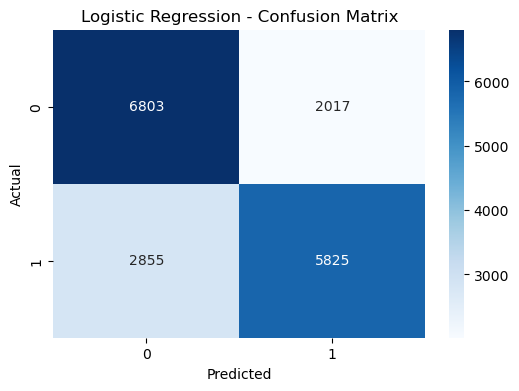

Decision Tree Accuracy: 63.67%

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.64      0.64      8820
           1       0.63      0.63      0.63      8680

    accuracy                           0.64     17500
   macro avg       0.64      0.64      0.64     17500
weighted avg       0.64      0.64      0.64     17500



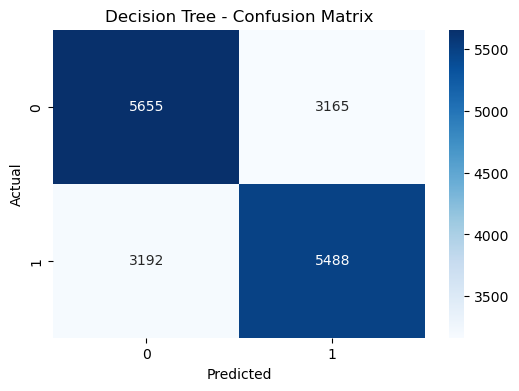

Support Vector Machine Accuracy: 72.18%

Support Vector Machine Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.81      0.75      8820
           1       0.77      0.63      0.69      8680

    accuracy                           0.72     17500
   macro avg       0.73      0.72      0.72     17500
weighted avg       0.73      0.72      0.72     17500



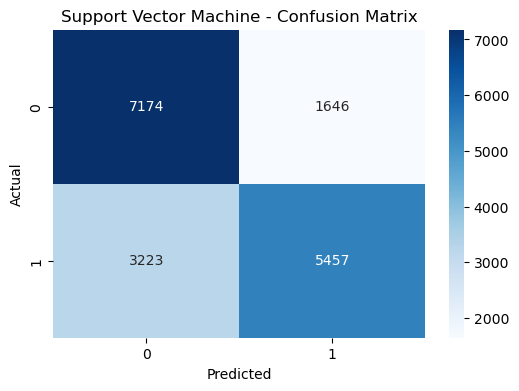

In [44]:
evaluate_model(y_test, logreg_pred, "Logistic Regression")
evaluate_model(y_test, decision_tree_pred, "Decision Tree")
evaluate_model(y_test, svm_pred, "Support Vector Machine")

### Hyperparameter Tuning with GridSearchCV

#### 1. Logistic Regression

In [45]:
param_grid_log = {'C': [0.1, 1, 10], 'solver': ['liblinear', 'saga']}
grid_log_reg = GridSearchCV(LogisticRegression(random_state=42), param_grid_log, cv=5, scoring='accuracy')
grid_log_reg.fit(X_train, y_train)

print(f"Best Logistic Regression Parameters: {grid_log_reg.best_params_}")
print(f"Best Logistic Regression Accuracy: {grid_log_reg.best_score_ * 100:.2f}%")


Best Logistic Regression Parameters: {'C': 10, 'solver': 'liblinear'}
Best Logistic Regression Accuracy: 72.27%


#### 2. Decision Tree

In [46]:
param_grid_tree = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_tree = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_tree, cv=5, scoring='accuracy')
grid_tree.fit(X_train, y_train)

print(f"Best Decision Tree Parameters: {grid_tree.best_params_}")
print(f"Best Decision Tree Accuracy: {grid_tree.best_score_ * 100:.2f}%")

Best Decision Tree Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Decision Tree Accuracy: 73.02%


#### 3. SVM

In [ ]:
# SVM Hyperparameter Tuning
param_grid_svm = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
grid_svm = GridSearchCV(SVC(random_state=42), param_grid_svm, cv=5, scoring='accuracy')
grid_svm.fit(X_train, y_train)

print(f"Best SVM Parameters: {grid_svm.best_params_}")
print(f"Best SVM Accuracy: {grid_svm.best_score_ * 100:.2f}%")

# This code can take long to execute, if it takes too much time then interrupt the kernel and re execute.